In [ ]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from google.colab import files

In [ ]:
#Load the dataset
df = pd.read_excel('/content/drive/MyDrive/Fortray/Healthcare/Dataset/data.xlsx')

In [ ]:
# Printing top 5 rows to see if the dataset is loaded
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print(df.shape)

(303, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


The dataset contains 303 rows and 14 columns. All features are numeric (13 integer columns and 1 float column)

In [ ]:
# Checking missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Checking duplicate values
print(df.duplicated().sum())

1


There is 1 duplicate row present in the dataset

In [ ]:
# Removing duplicates
df.drop_duplicates(inplace=True)
print(df.shape)

(302, 14)


**Let's explore the measures of central tendencies and the spread of the data.**

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Insights from the Statistical Summary:

1. Age: The patients' ages range from a minimum of 29 years to a maximum of 77 years, with a mean (average) age of ~54.4 years.

2. Resting Blood Pressure (trestbps): Averages around 131.6 mm Hg, with the highest reading going up to 200 mm Hg.

3. Cholesterol (chol): The average cholesterol level is 246.5 mg/dl. The maximum value is very high at 564 mg/dl, which could indicate some outliers.

4. Maximum Heart Rate (thalach): Spans from 71 to 202 bpm, with an average of 149.6 bpm.

5. Target: The mean of the target variable is ~0.54, which tells us that the dataset is fairly balanced (about 54% of patients in this dataset have the cardiovascular disease outcome, and 46% do not).

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Let's identify and explore categorical values. Based on the variable descriptions, the data contains several categorical features:

/tmp/ipykernel_898/742930492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes1[i], palette='viridis')
/tmp/ipykernel_898/742930492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes1[i], palette='viridis')
/tmp/ipykernel_898/742930492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes1[i], palette='viridis')
/tmp/ipykernel_898/742930492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

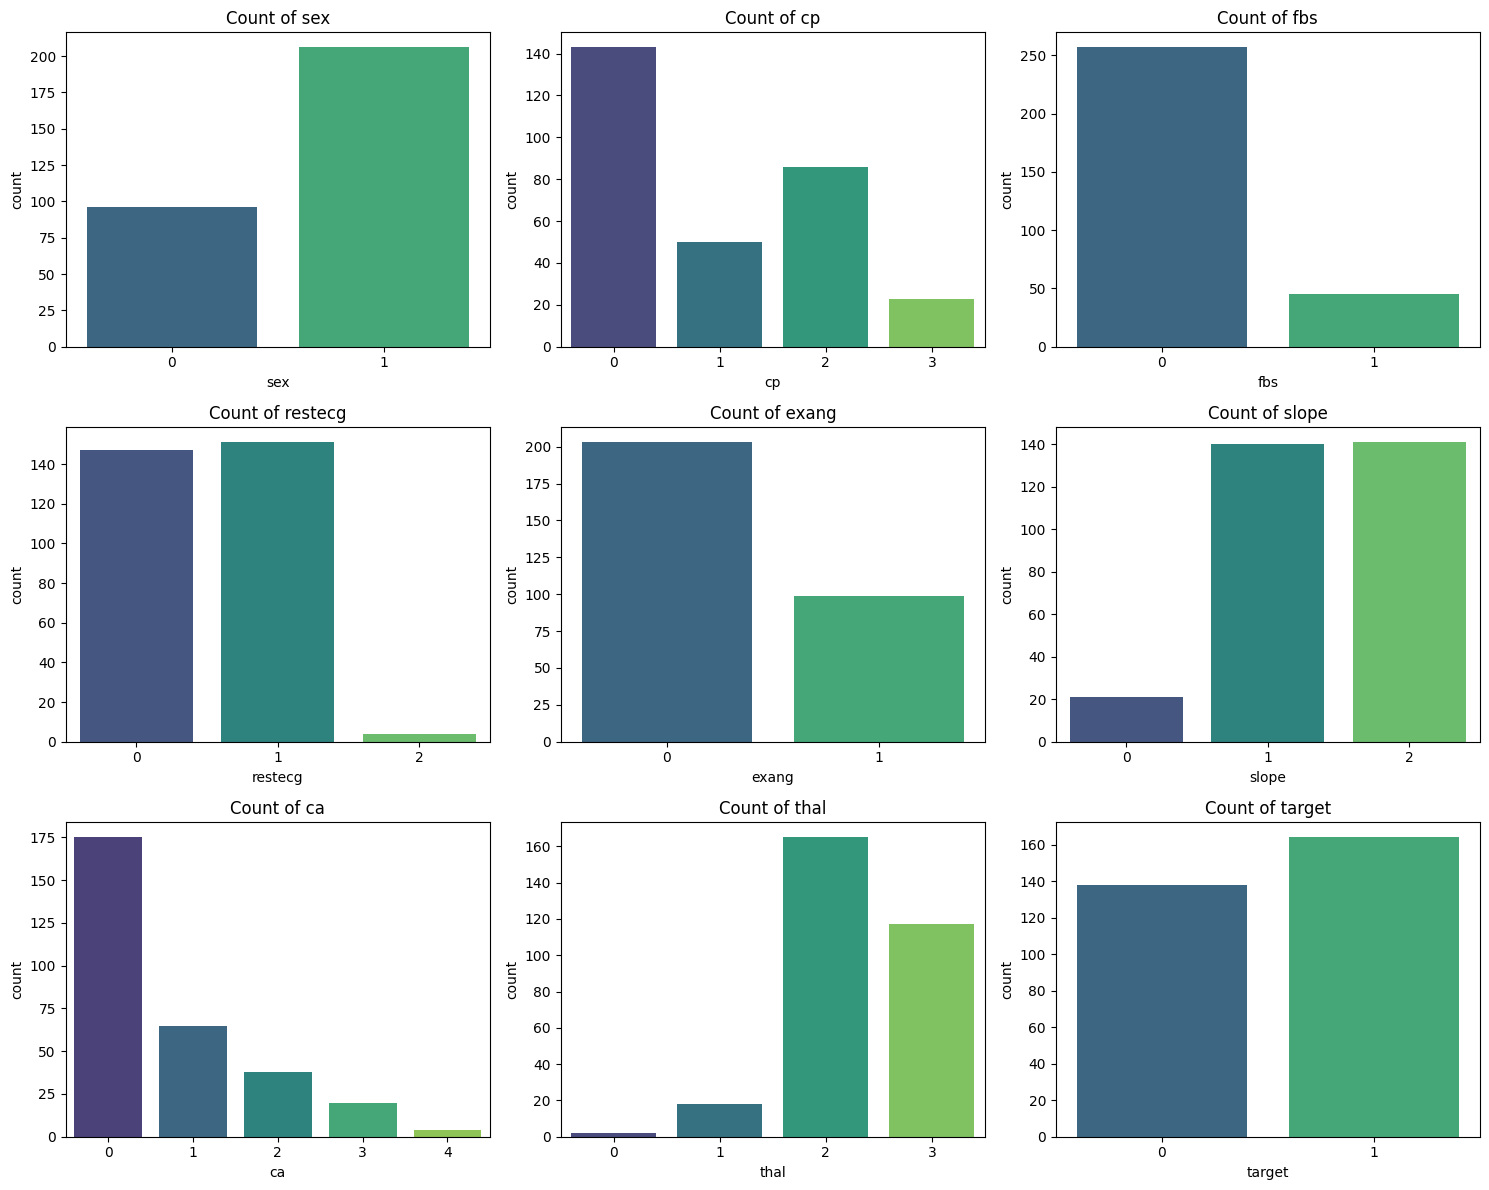

In [ ]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

# Exploring the variables using count plot
fig1, axes1 = plt.subplots(3, 3, figsize=(15, 12))
axes1 = axes1.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes1[i], palette='viridis')
    axes1[i].set_title(f'Count of {col}')

fig1.tight_layout()
fig1.savefig('categorical_counts.png')

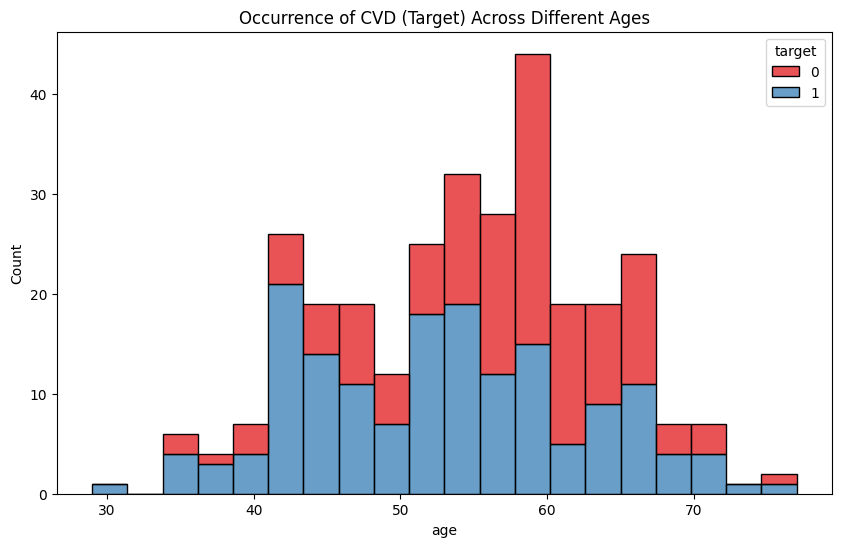

In [ ]:
# Studying the occurrence of CVD across different ages
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', multiple='stack', bins=20, palette='Set1', ax=ax2)
ax2.set_title('Occurrence of CVD (Target) Across Different Ages')
fig2.savefig('cvd_by_age.png')

Patients who have heart disease (target=1) peak in their early to mid-50s. For patients in their 40s and early 50s, the proportion of target=1 is noticeably higher than target=0. Interestingly, past the age of 60, the trend flips, and there are more patients without the disease in this specific dataset than with it.

/tmp/ipykernel_898/1958140060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='trestbps', palette='Set2', ax=ax3)


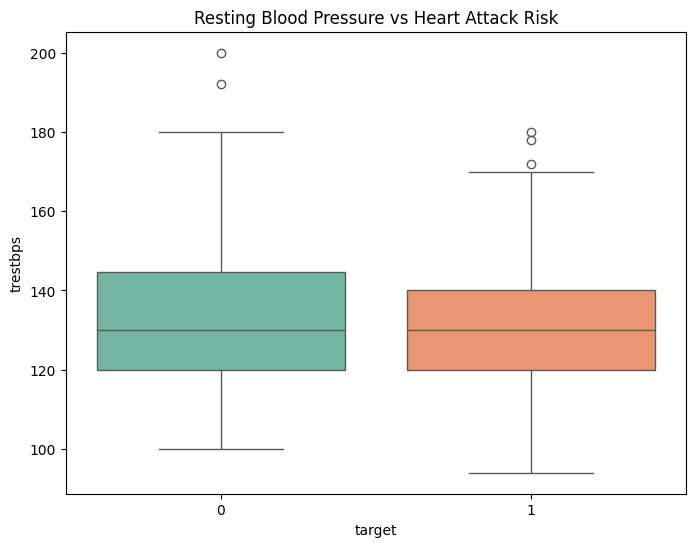

In [ ]:
# Anomalies in resting blood pressure
fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='target', y='trestbps', palette='Set2', ax=ax3)
ax3.set_title('Resting Blood Pressure vs Heart Attack Risk')
fig3.savefig('trestbps_vs_target.png')

The median resting blood pressure is almost identical for both groups (around 130 mm Hg). While there are some anomalies/outliers (patients with blood pressure above 170 mm Hg), these outliers exist in both the healthy (target=0) and diseased (target=1) groups. We cannot effectively detect a heart attack based solely on anomalies in resting blood pressure, because the distributions between the two groups are too similar.

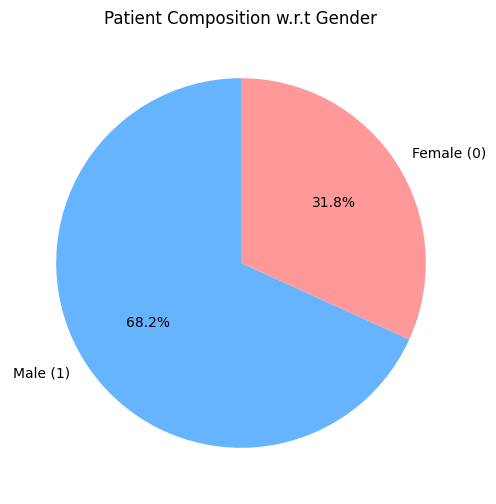

In [ ]:
# composition of overall patients w.r.t gender
fig4, ax4 = plt.subplots(figsize=(6, 6))
gender_counts = df['sex'].value_counts()
ax4.pie(gender_counts, labels=['Male (1)', 'Female (0)'], autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999'])
ax4.set_title('Patient Composition w.r.t Gender')
fig4.savefig('gender_composition.png')

pie chart reveals that the dataset is highly skewed towards males. Males (1) make up 68.2% of the patients, while females (0) make up 31.8%.

/tmp/ipykernel_898/2345144383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='Set2')


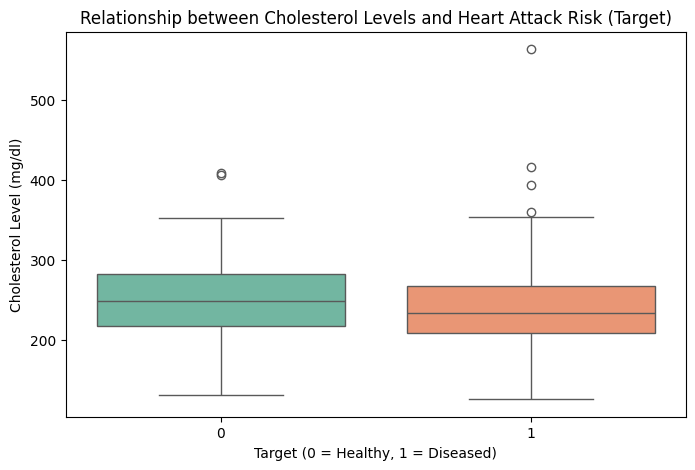

In [ ]:
# Create a box plot to compare cholesterol levels between the two target groups
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Relationship between Cholesterol Levels and Heart Attack Risk (Target)')
plt.xlabel('Target (0 = Healthy, 1 = Diseased)')
plt.ylabel('Cholesterol Level (mg/dl)')
plt.show()

The median cholesterol level for patients with heart disease (target = 1) is actually slightly lower than the median cholesterol level for healthy patients (target = 0) in this specific dataset. Both groups have outliers (patients with cholesterol levels well above 350 mg/dl), with one extreme outlier in the diseased group hitting past 500 mg/dl.

/tmp/ipykernel_898/3725949629.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='thalach', data=df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_898/3725949629.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='oldpeak', data=df, ax=axes[1], palette='coolwarm')


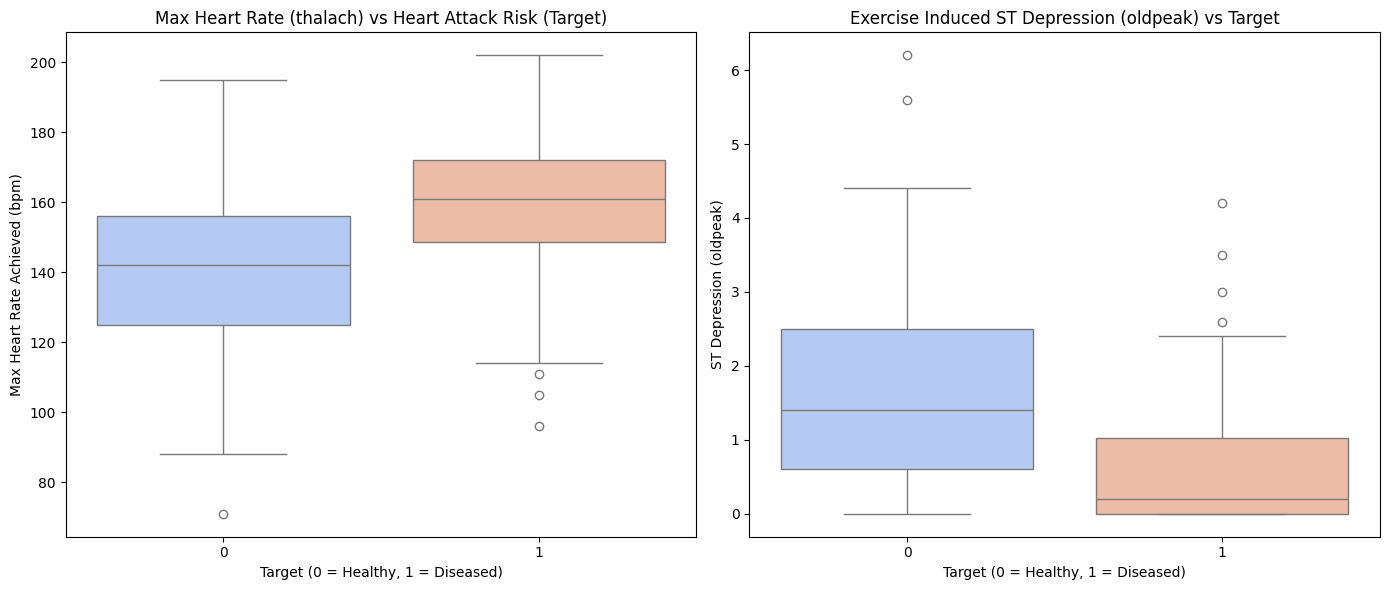

In [ ]:
# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Maximum Heart Rate (thalach) vs Target
sns.boxplot(x='target', y='thalach', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Max Heart Rate (thalach) vs Heart Attack Risk (Target)')
axes[0].set_xlabel('Target (0 = Healthy, 1 = Diseased)')
axes[0].set_ylabel('Max Heart Rate Achieved (bpm)')

# Plot 2: ST Depression (oldpeak) vs Target
sns.boxplot(x='target', y='oldpeak', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Exercise Induced ST Depression (oldpeak) vs Target')
axes[1].set_xlabel('Target (0 = Healthy, 1 = Diseased)')
axes[1].set_ylabel('ST Depression (oldpeak)')

plt.tight_layout()
plt.show()


* Maximum Heart Rate (thalach): The boxplot on the left shows a clear trend. Patients who are at a higher risk of a heart attack (target = 1) tend to achieve a higher maximum heart rate during peak exercise compared to healthy patients. The median for the diseased group is significantly higher.

* ST Depression (oldpeak): The boxplot on the right shows that patients at risk of a heart attack (target = 1) have a much lower ST depression induced by exercise compared to healthy individuals (target = 0). The healthy group tends to experience greater ST depression during exercise.

* Peak exercising metrics are strong indicators! People who achieve unusually high maximum heart rates but show lower levels of exercise-induced ST depression in this dataset are strongly associated with a higher occurrence of heart attacks.

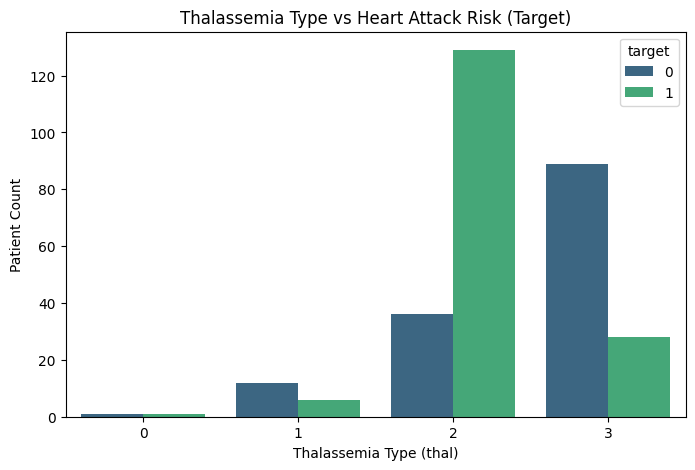

Patient Counts by Thalassemia Type and Target:
thal  target
0     0           1
      1           1
1     0          12
      1           6
2     0          36
      1         129
3     0          89
      1          28
dtype: int64


In [ ]:
# Create a count plot to see the distribution of thalassemia types grouped by target
plt.figure(figsize=(8, 5))
sns.countplot(x='thal', hue='target', data=df, palette='viridis')
plt.title('Thalassemia Type vs Heart Attack Risk (Target)')
plt.xlabel('Thalassemia Type (thal)')
plt.ylabel('Patient Count')
plt.show()

# Print the exact numbers to be sure
print("Patient Counts by Thalassemia Type and Target:")
print(df.groupby(['thal', 'target']).size())

* In our dataset, thal takes on a few values (0, 1, 2, and 3).

* Patients with Thalassemia Type 2 have a massive spike in heart disease risk. Out of all the patients with Type 2, 129 are at risk of a heart attack (target = 1) while only 36 are healthy (target = 0).

* Conversely, patients with Thalassemia Type 3 are overwhelmingly healthy (89 healthy vs. 28 diseased).

* The type of thalassemia a patient has is a very strong indicator of whether they are at high risk for a heart attack. Type 2 is highly associated with CVD.

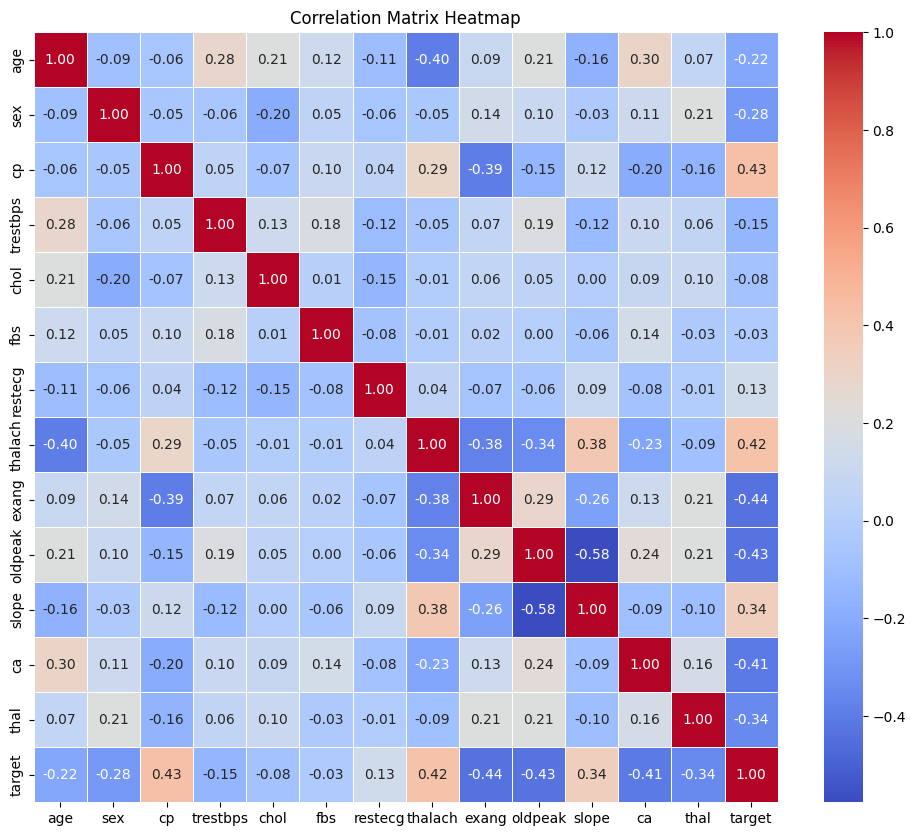

In [ ]:
# Lets find the relationship between features using corelation matrix
corr_matrix = df.corr()

# Visualize the correlation matrix using a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

There are three variables that stand out as having the most significant relationship with heart disease:



1. Chest Pain Type (cp): This has the strongest positive correlation. This means that as the chest pain category increases (specifically moving toward non-anginal pain), the likelihood of a heart attack risk (target=1) increases significantly.
2. Maximum Heart Rate (thalach): Also a strong positive correlation. Patients who are able to achieve higher heart rates during exercise are statistically more likely to be in the high-risk group in this dataset.
3. Exercise-Induced Angina (exang): This has a strong negative correlation. This means that patients who do not experience chest pain during exercise (angina) are actually more frequently found in the "at-risk" (target=1) group in this specific study.


Physical Indicators that Lower Risk




1. Number of Major Vessels (ca): This has a strong negative relationship. The more major vessels that are clear (colored by fluoroscopy), the lower the risk of a heart attack. This makes sense medically clear vessels mean better blood flow.
2. ST Depression (oldpeak): Higher levels of ST depression (a specific ECG reading) are associated with lower risk in this dataset.

Cholesterol (chol) and Fasting Blood Sugar (fbs): These bars are almost at zero.

While we usually think of cholesterol as the main cause of heart issues, in this specific group of 302 patients, cholesterol levels were not a reliable way to tell who was healthy and who was at risk.

In [ ]:
# Prepairing the data
# X contains all the features, y contains only the target outcome
X = df.drop('target', axis=1)
y = df['target']

# Split the data
# We use 80% of the data to train the model, and hold back 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train the Logistic Regression model
# max_iter=1000 gives the model enough time to find the best fit
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict on the test data
y_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Validate the results using a Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Our model achieved an overall accuracy of 82%. This means it correctly predicted whether a patient was healthy or diseased 82% of the time based solely on their medical metrics

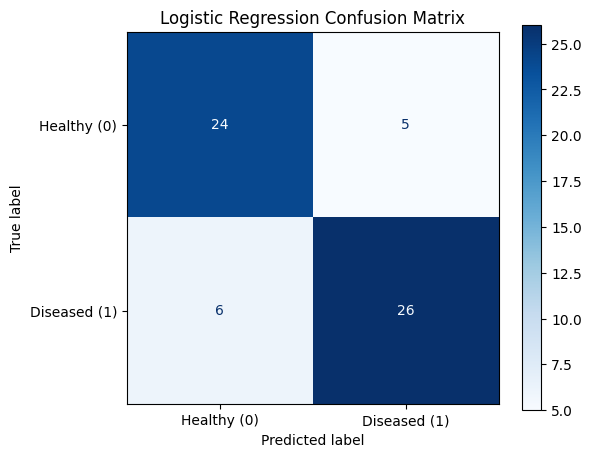

In [ ]:
# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Diseased (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

True Negatives. The model correctly predicted 24 healthy patients as healthy.

True Positives. The model correctly predicted 26 diseased patients as diseased.

False Positives. The model incorrectly predicted 5 healthy patients as having heart disease.

False Negatives. The model incorrectly predicted 6 diseased patients as being healthy (this is the most dangerous error in medical testing!).

To increase the accuracy, we are going to do two main things:

Feature Scaling: Right now, our variables are wildly different sizes. Cholesterol is up in the 200-300 range, while ST Depression (oldpeak) is between 0 and 6. Logistic regression struggles with this. We will use a StandardScaler to shrink all variables so they share the same scale.

Hyperparameter Tuning: Models have built-in "settings" (hyperparameters). We will use a tool called GridSearchCV, which essentially tries dozens of different setting combinations automatically and picks the absolute best one for our specific dataset.

In [ ]:
# This standardizes all variables to have a mean of 0 and standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform the test data, never fit!

In [ ]:
# We give it a grid of different settings to test
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # How strictly it penalizes errors
    'penalty': ['l1', 'l2'],             # Types of regularization
    'solver': ['liblinear', 'saga']      # The algorithm calculating the math
}

# Initialize a fresh model and the Grid Search tool
log_model_base = LogisticRegression(max_iter=5000, random_state=42)
grid_search = GridSearchCV(log_model_base, param_grid, cv=5, scoring='accuracy')

# Let it test all the combinations on our scaled training data!
grid_search.fit(X_train_scaled, y_train)

# Print the winning settings
print("Best Model Settings Found")
print(grid_search.best_params_)

Best Model Settings Found
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# Predict using the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

In [ ]:

# Validate the tuned results
print("Tuned Classification Report")
print(classification_report(y_test, y_pred_tuned))

Tuned Classification Report
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



Overall accuracy went from 82% to 84%

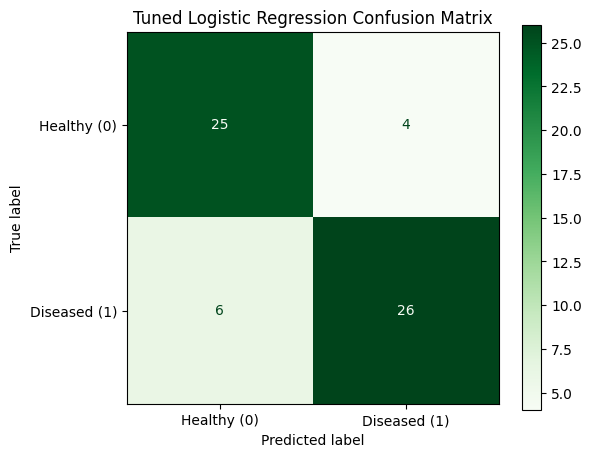

In [ ]:
# Plot the new Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Healthy (0)', 'Diseased (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Greens', ax=ax)
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.show()

In our original matrix, we had 5 "False Positives" (predicting a healthy person was diseased). Our newly tuned model reduced that to 4. It correctly identified an additional healthy person.